# Weight Loss Medication FAERS Analysis

This notebook loads FAERS data downloaded by `scripts/download_faers_wl.py` and inspects signals.

For the full LLM vs Dictionary vs FAERS pipeline (matching the antidepressant study), run:
- `scripts/run_all.py` or
- `AE_Signal_Detection_WL_LLM_vs_Dictionary_vs_FAERS.ipynb`


In [24]:
!pip install pandas requests tqdm

In [25]:
import json
import os
from pathlib import Path
from urllib.parse import quote_plus

import pandas as pd
import requests
from tqdm import tqdm

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)

WEIGHT_LOSS_DRUG_LIST = BASE_DIR / "weight_loss_drug_list.csv"
FAERS_JSON_PATH = DATA_DIR / "faers_weight_loss_events.json"
FAERS_CSV_PATH = DATA_DIR / "faers_weight_loss_events.csv"

print(f"Workspace: {BASE_DIR}")
print(f"Drug list: {WEIGHT_LOSS_DRUG_LIST}")
print(f"FAERS path: {FAERS_JSON_PATH}")

Workspace: /Users/alexandarvincentpaulraj/Projects/TheEx/Weight Loss Meds
Drug list: /Users/alexandarvincentpaulraj/Projects/TheEx/Weight Loss Meds/weight_loss_drug_list.csv
FAERS path: /Users/alexandarvincentpaulraj/Projects/TheEx/Weight Loss Meds/data/faers_weight_loss_events.json


In [26]:
# Load the weight loss drug list and inspect it
weight_loss_df = pd.read_csv(WEIGHT_LOSS_DRUG_LIST)
weight_loss_df.head(20)

,variant,generic_name,mapping_type
0,tanzeum,albiglutide,brand/commercial
1,didrex,benzphetamine,brand/commercial
2,invokana,canagliflozin,brand/commercial
3,plenity,cellulose and citric acid hydrogel,brand/commercial
4,farxiga,dapagliflozin,brand/commercial
5,forxiga,dapagliflozin,brand/commercial
6,dapaglifozin,dapagliflozin,misspelling
7,tenuate,diethylpropion,brand/commercial
8,tenuate dospan,diethylpropion,brand/commercial
9,trulicity,dulaglutide,brand/commercial


In [27]:
# Build a normalized list of generic and brand names to search in FAERS/OpenFDA
weight_loss_df = weight_loss_df.dropna(subset=["variant", "generic_name"])
weight_loss_df["variant"] = weight_loss_df["variant"].astype(str).str.strip()
weight_loss_df["generic_name"] = weight_loss_df["generic_name"].astype(str).str.strip()

brand_names = sorted(weight_loss_df.loc[weight_loss_df["mapping_type"].str.contains("brand|commercial|misspelling", case=False, na=False), "variant"].unique())
generic_names = sorted(weight_loss_df["generic_name"].unique())

print(f"Unique generic names: {len(generic_names)}")
print(f"Unique brand/misspelling names: {len(brand_names)}")
print(generic_names)

Unique generic names: 24
Unique brand/misspelling names: 108
['albiglutide', 'benzphetamine', 'canagliflozin', 'cellulose and citric acid hydrogel', 'dapagliflozin', 'diethylpropion', 'dulaglutide', 'empagliflozin', 'ertugliflozin', 'exenatide', 'liraglutide', 'lixisenatide', 'lorcaserin', 'metformin', 'naltrexone', 'naltrexone/bupropion', 'orlistat', 'phendimetrazine', 'phentermine', 'phentermine/topiramate', 'semaglutide', 'setmelanotide', 'tirzepatide', 'topiramate']


In [28]:
# Download FAERS via fixed OpenFDA pipeline (brand + generic queries, no 800 cap)
import subprocess
import sys

force = False  # set True to re-download
cmd = [sys.executable, "scripts/download_faers_wl.py"]
if force:
    cmd.append("--force")
subprocess.run(cmd, check=True)

import json
with FAERS_JSON_PATH.open("r", encoding="utf-8") as fh:
    faers_data = json.load(fh)
print(f"Loaded {len(faers_data.get('results', [])):,} FAERS events")
print("Aggregated FAERS table:", DATA_DIR / "4.FAERS_data.csv")


Loading cached FAERS data...
Loaded 800 FAERS events


In [29]:
def extract_drug_names(event):
    drug_list = event.get("patient", {}).get("drug", [])
    return [d.get("medicinalproduct", "").strip().lower() for d in drug_list if d.get("medicinalproduct")]


def extract_reactions(event):
    reaction_list = event.get("patient", {}).get("reaction", [])
    return [r.get("reactionmeddrapt", "").strip().lower() for r in reaction_list if r.get("reactionmeddrapt")]


results = faers_data.get("results", [])
print(f"Number of raw FAERS event entries: {len(results):,}")

records = []
for event in results:
    records.append({
        "safetyreportid": event.get("safetyreportid"),
        "receivedate": event.get("receivedate"),
        "serious": event.get("serious"),
        "occurcountry": event.get("occurcountry"),
        "drug_names": extract_drug_names(event),
        "reactions": extract_reactions(event),
    })

faers_events_df = pd.DataFrame(records)
faers_events_df["drug_names_count"] = faers_events_df["drug_names"].apply(len)
faers_events_df.head(10)

Number of raw FAERS event entries: 800


,safetyreportid,receivedate,serious,occurcountry,drug_names,reactions,drug_names_count
0,10006258,20140313,1,US,"[victoza, januvia, janumet, byetta, onglyza]",[pancreatic carcinoma],5
1,10006261,20140313,1,US,"[januvia, byetta, avandia, glyburide (microniz...",[pancreatic carcinoma],5
2,10006263,20140313,1,US,"[byetta, byetta, victoza, metformin, metformin...",[pancreatic carcinoma],6
3,10006277,20140313,1,US,"[victoza, byetta]",[thyroid cancer],2
4,10007906,20140313,1,DE,"[byetta pen disposable, metformin hcl, insulin]","[arterial occlusive disease, blood glucose inc...",3
5,10007909,20140313,1,US,"[bydureon, metformin hcl tabs]","[loss of consciousness, malaise, diarrhoea, bl...",2
6,10007913,20140313,1,US,"[byetta pen disposable, bydureon, exenatide 10...","[cardiac aneurysm, blood glucose increased, we...",5
7,10007966,20140313,1,US,"[byetta, onglyza tabs, januvia, janumet, victoza]",[pancreatic carcinoma],5
8,10007970,20140313,1,US,"[monopril, ferrous sulfate, byetta, cardura, b...",[pancreatic carcinoma],21
9,10007984,20140313,1,US,[vitamin e /00110501/...,[thyroid cancer],13


In [30]:
# Save a flattened CSV for local analysis
faers_events_df.to_csv(FAERS_CSV_PATH, index=False)
print(f"Saved flattened FAERS events CSV to {FAERS_CSV_PATH}")

# Basic signal summaries
print("\nTop reaction terms")
reaction_counts = pd.Series(
    [reaction for sub in faers_events_df["reactions"].tolist() for reaction in sub]
).value_counts().head(20)
print(reaction_counts)

print("\nTop reported drug names")
drug_counts = pd.Series(
    [drug for sub in faers_events_df["drug_names"].tolist() for drug in sub]
).value_counts().head(20)
print(drug_counts)

print("\nEvent counts by seriousness")
print(faers_events_df["serious"].value_counts(dropna=False))

print("\nEvent counts by country")
print(faers_events_df["occurcountry"].value_counts().head(20))

Saved flattened FAERS events CSV to /Users/alexandarvincentpaulraj/Projects/TheEx/Weight Loss Meds/data/faers_weight_loss_events.csv

Top reaction terms
drug ineffective                237
treatment noncompliance         165
rectal discharge                142
steatorrhoea                    136
product quality issue           103
diarrhoea                        86
weight increased                 64
drug administration error        59
constipation                     55
abdominal pain upper             49
frequent bowel movements         48
flatulence                       43
gastrointestinal disorder        39
nausea                           33
abdominal distension             30
faeces discoloured               30
dizziness                        23
faecal incontinence              23
therapeutic response changed     23
pancreatic carcinoma             23
Name: count, dtype: int64

Top reported drug names
alli                     717
byetta                    64
metformin         

In [31]:
# Normalize FAERS drug names against the weight loss drug list
weight_loss_df["variant_norm"] = weight_loss_df["variant"].str.lower().str.strip()
weight_loss_df["generic_norm"] = weight_loss_df["generic_name"].str.lower().str.strip()

variant_to_generic = dict(zip(weight_loss_df["variant_norm"], weight_loss_df["generic_norm"]))
known_generics = sorted(weight_loss_df["generic_norm"].unique())

ROLE_LABELS = {
    "1": "primary suspect",
    "2": "secondary suspect",
    "3": "concomitant",
    "4": "interacting",
    "PS": "primary suspect",
    "SS": "secondary suspect",
    "C": "concomitant",
    "I": "interacting",
}


def normalize_weight_loss_drug(raw_name):
    raw = str(raw_name or "").lower().strip()
    if not raw:
        return None
    raw = raw.replace('"', '').replace("'", "")
    for variant, generic in variant_to_generic.items():
        if variant and variant in raw:
            return generic
    for generic in known_generics:
        if generic and generic in raw:
            return generic
    return None


def extract_drug_info(event):
    drug_list = event.get("patient", {}).get("drug", [])
    parsed = []
    for drug in drug_list:
        raw_name = drug.get("medicinalproduct", "")
        normalized = normalize_weight_loss_drug(raw_name)
        drug_role = str(drug.get("drugcharacterization") or drug.get("role_cod") or "").strip()
        parsed.append({
            "raw_name": raw_name,
            "normalized_name": normalized,
            "role": ROLE_LABELS.get(drug_role, drug_role or None),
        })
    return parsed


records = []
for event in results:
    drug_info = extract_drug_info(event)
    normalized_drugs = [d["normalized_name"] for d in drug_info if d["normalized_name"]]
    primary_suspects = [d["normalized_name"] for d in drug_info if d["role"] == "primary suspect" and d["normalized_name"]]

    records.append({
        "safetyreportid": event.get("safetyreportid"),
        "receivedate": event.get("receivedate"),
        "serious": event.get("serious"),
        "occurcountry": event.get("occurcountry"),
        "drug_names": extract_drug_names(event),
        "drug_info": drug_info,
        "normalized_drugs": sorted(set(normalized_drugs)),
        "primary_suspect_drugs": sorted(set(primary_suspects)),
        "drug_names_count": len(drug_info),
        "reactions": extract_reactions(event),
    })

faers_events_df = pd.DataFrame(records)
faers_events_df["drug_normalized_count"] = faers_events_df["normalized_drugs"].apply(len)
faers_events_df["primary_suspect_count"] = faers_events_df["primary_suspect_drugs"].apply(len)
faers_events_df.head(10)

,safetyreportid,receivedate,serious,occurcountry,drug_names,drug_info,normalized_drugs,primary_suspect_drugs,drug_names_count,reactions,drug_normalized_count,primary_suspect_count
0,10006258,20140313,1,US,"[victoza, januvia, janumet, byetta, onglyza]","[{'raw_name': 'VICTOZA', 'normalized_name': 'l...","[exenatide, liraglutide]","[exenatide, liraglutide]",5,[pancreatic carcinoma],2,2
1,10006261,20140313,1,US,"[januvia, byetta, avandia, glyburide (microniz...","[{'raw_name': 'JANUVIA', 'normalized_name': No...","[exenatide, liraglutide]","[exenatide, liraglutide]",5,[pancreatic carcinoma],2,2
2,10006263,20140313,1,US,"[byetta, byetta, victoza, metformin, metformin...","[{'raw_name': 'BYETTA', 'normalized_name': 'ex...","[exenatide, liraglutide, metformin]","[exenatide, liraglutide]",6,[pancreatic carcinoma],3,2
3,10006277,20140313,1,US,"[victoza, byetta]","[{'raw_name': 'VICTOZA', 'normalized_name': 'l...","[exenatide, liraglutide]","[exenatide, liraglutide]",2,[thyroid cancer],2,2
4,10007906,20140313,1,DE,"[byetta pen disposable, metformin hcl, insulin]","[{'raw_name': 'BYETTA PEN DISPOSABLE', 'normal...","[exenatide, metformin]","[exenatide, metformin]",3,"[arterial occlusive disease, blood glucose inc...",2,2
5,10007909,20140313,1,US,"[bydureon, metformin hcl tabs]","[{'raw_name': 'BYDUREON', 'normalized_name': '...","[exenatide, metformin]","[exenatide, metformin]",2,"[loss of consciousness, malaise, diarrhoea, bl...",2,2
6,10007913,20140313,1,US,"[byetta pen disposable, bydureon, exenatide 10...","[{'raw_name': 'BYETTA PEN DISPOSABLE', 'normal...","[exenatide, metformin]",[exenatide],5,"[cardiac aneurysm, blood glucose increased, we...",2,1
7,10007966,20140313,1,US,"[byetta, onglyza tabs, januvia, janumet, victoza]","[{'raw_name': 'BYETTA', 'normalized_name': 'ex...","[exenatide, liraglutide]","[exenatide, liraglutide]",5,[pancreatic carcinoma],2,2
8,10007970,20140313,1,US,"[monopril, ferrous sulfate, byetta, cardura, b...","[{'raw_name': 'MONOPRIL', 'normalized_name': N...","[exenatide, metformin]",[exenatide],21,[pancreatic carcinoma],2,1
9,10007984,20140313,1,US,[vitamin e /00110501/...,[{'raw_name': 'VITAMIN E ...,"[exenatide, metformin]",[exenatide],13,[thyroid cancer],2,1


In [32]:
# Save the richer flattened CSV for local analysis
faers_events_df.to_csv(FAERS_CSV_PATH, index=False)
print(f"Saved richer FAERS events CSV to {FAERS_CSV_PATH}")

# Drug-class mapping summary
normalized_counts = pd.Series([drug for entry in faers_events_df["normalized_drugs"].tolist() for drug in entry])
print("\nTop weight loss drug classes in FAERS events")
print(normalized_counts.value_counts().head(30))

# Reaction co-occurrence of the top terms
reaction_counts = pd.Series([reaction for entry in faers_events_df["reactions"].tolist() for reaction in entry])
top_reactions = set(reaction_counts.value_counts().head(30).index)

pair_counts = {}
for reactions in faers_events_df["reactions"]:
    unique_reactions = sorted(set(reactions) & top_reactions)
    for i in range(len(unique_reactions)):
        for j in range(i + 1, len(unique_reactions)):
            pair = (unique_reactions[i], unique_reactions[j])
            pair_counts[pair] = pair_counts.get(pair, 0) + 1

pair_counts_series = pd.Series(pair_counts).sort_values(ascending=False).head(30)
print("\nTop reaction co-occurring pairs")
print(pair_counts_series)

# Drug role filtering summary
role_counts = pd.Series([d["role"] for entry in faers_events_df["drug_info"] for d in entry if d["role"]])
print("\nDrug role distribution in FAERS events")
print(role_counts.value_counts())

primary_suspect_events = faers_events_df[faers_events_df["primary_suspect_count"] > 0]
print(f"\nEvents with at least one normalized primary suspect weight loss drug: {len(primary_suspect_events):,}")

print("\nTop primary suspect drug classes")
primary_suspect_counts = pd.Series([drug for entry in primary_suspect_events["primary_suspect_drugs"].tolist() for drug in entry])
print(primary_suspect_counts.value_counts().head(20))

Saved richer FAERS events CSV to /Users/alexandarvincentpaulraj/Projects/TheEx/Weight Loss Meds/data/faers_weight_loss_events.csv

Top weight loss drug classes in FAERS events
orlistat       717
exenatide       75
metformin       29
liraglutide     15
lorcaserin       6
phentermine      2
Name: count, dtype: int64

Top reaction co-occurring pairs
drug ineffective           product quality issue        83
                           treatment noncompliance      60
steatorrhoea               treatment noncompliance      58
rectal discharge           treatment noncompliance      54
product quality issue      treatment noncompliance      46
drug ineffective           weight increased             41
                           rectal discharge             35
                           steatorrhoea                 35
product quality issue      steatorrhoea                 34
                           rectal discharge             30
                           weight increased             24
re

In [33]:
# Download quarter-specific FAERS archive from FDA public datasets
import tempfile
import zipfile


def download_faers_archive(year, quarter, output_root=DATA_DIR / "faers_archives", redownload=False):
    output_root.mkdir(parents=True, exist_ok=True)
    archive_name = f"faers_ascii_{year}q{quarter}.zip"
    archive_path = output_root / archive_name
    extract_dir = output_root / f"{year}q{quarter}"

    if archive_path.exists() and extract_dir.exists() and not redownload:
        print(f"Archive already downloaded and extracted: {archive_path}")
        return extract_dir

    url = f"https://fis.fda.gov/content/Exports/{archive_name}"
    print(f"Downloading FAERS archive: {url}")
    with requests.get(url, stream=True, timeout=60) as response:
        response.raise_for_status()
        with open(archive_path, "wb") as fh:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    fh.write(chunk)

    print(f"Extracting archive to {extract_dir}")
    with zipfile.ZipFile(archive_path, "r") as zf:
        zf.extractall(extract_dir)

    return extract_dir

archive_dir = download_faers_archive(2024, 1)
print(f"Quarter archive available at: {archive_dir}")
print("Files extracted:")
for path in sorted(archive_dir.glob("**/*")):
    print(f"- {path.name}")

Archive already downloaded and extracted: /Users/alexandarvincentpaulraj/Projects/TheEx/Weight Loss Meds/data/faers_archives/faers_ascii_2024q1.zip
Quarter archive available at: /Users/alexandarvincentpaulraj/Projects/TheEx/Weight Loss Meds/data/faers_archives/2024q1
Files extracted:
- ASCII
- ASC_NTS.pdf
- DEMO24Q1.pdf
- DEMO24Q1.txt
- DRUG24Q1.pdf
- DRUG24Q1.txt
- INDI24Q1.pdf
- INDI24Q1.txt
- OUTC24Q1.pdf
- OUTC24Q1.txt
- REAC24Q1.pdf
- REAC24Q1.txt
- RPSR24Q1.pdf
- RPSR24Q1.txt
- THER24Q1.pdf
- THER24Q1.txt
- Deleted
- DELETE24Q1.txt
- FAQs.pdf
- Readme.pdf


In [34]:
# Review related existing work and files so we can compare the FAERS output
notes_path = BASE_DIR / "LLM_processing_WL.md"
if notes_path.exists():
    with notes_path.open("r", encoding="utf-8") as fh:
        lines = fh.readlines()
    print("Loaded LLM_processing_WL.md summary lines:\n")
    print("".join(lines[:40]))
else:
    print("LLM_processing_WL.md not found in the workspace.")

related_csvs = [p.name for p in BASE_DIR.glob("*.csv") if p.name.lower().startswith(("after_drug_filtering", "drug_normalization_audit", "gemini_results_combined"))]
print("\nRelated existing CSVs for comparison:")
for csv_file in related_csvs:
    print(f"- {csv_file}")

Loaded LLM_processing_WL.md summary lines:

# LLM Processing — Weight Loss Medication Reddit Data

---

## Setup

```python
!pip install pandas
```

---

## Step 1 — Raw to Clean: Extract & Parse JSONL Files

Reads all `.jsonl` post files from the `Posts/` directory, selects the desired fields, derives `created_dt` / `created_date` from `created_utc`, and writes cleaned files to `WL posts cleaned/`. Produces an audit CSV (`step1_raw_to_clean_audit.csv`).

```python
import json
import os
import pandas as pd
from datetime import datetime, timezone

# --- Configuration ---
SOURCE_DIR = "/Volumes/Poornima/Weight loss Medication /Reddit Data/Posts"
OUTPUT_DIR = "/Volumes/Poornima/Weight loss Medication /Reddit Data/WL posts cleaned"

# Fields to keep (from raw JSONL)
RAW_FIELDS = [
    'id','created_utc', 'author', 'author_fullname', 'subreddit',
    'subreddit_subscribers', 'url', 'ups', 'upvote_ratio',
    'num_comments', 'score', 'permalink', 'author_flair_text',
    'link_flair_text', '

In [35]:
import math
from collections import Counter

# Build report-level sets for drug and reaction analysis
faers_analysis = faers_events_df.copy()
faers_analysis["reaction_set"] = faers_analysis["reactions"].apply(lambda x: set(x) if isinstance(x, list) else set())
faers_analysis["drug_set"] = faers_analysis["normalized_drugs"].apply(lambda x: set(x) if isinstance(x, list) else set())
faers_analysis["primary_suspect_set"] = faers_analysis["primary_suspect_drugs"].apply(lambda x: set(x) if isinstance(x, list) else set())

N = len(faers_analysis)
print(f"Total FAERS reports for analysis: {N}")

# Use the top observed reactions and top weight loss drug classes to keep the disproportionality table manageable
reaction_counts = pd.Series([reaction for reactions in faers_analysis["reaction_set"] for reaction in reactions]).value_counts()
drug_counts = pd.Series([drug for drugs in faers_analysis["normalized_drugs"] for drug in (drugs or [])]).value_counts()

top_reactions = reaction_counts.head(80).index.tolist()
top_drugs = drug_counts.head(40).index.tolist()
print(f"Computed {len(top_drugs)} top drugs and {len(top_reactions)} top reaction candidates")

prr_rows = []
for drug in top_drugs:
    drug_mask = faers_analysis["drug_set"].apply(lambda s: drug in s)
    n_drug = int(drug_mask.sum())
    if n_drug < 3:
        continue

    for reaction in top_reactions:
        reaction_mask = faers_analysis["reaction_set"].apply(lambda s: reaction in s)
        a = int((drug_mask & reaction_mask).sum())
        if a < 3:
            continue

        b = int(n_drug - a)
        c = int(reaction_mask.sum() - a)
        d = int(N - a - b - c)
        if b <= 0 or c <= 0 or d <= 0:
            continue

        prr = (a / (a + b)) / (c / (c + d))
        ror = (a / b) / (c / d) if b > 0 and d > 0 else float("nan")
        chi2 = ((a * d - b * c) ** 2) * N / ((a + b) * (c + d) * (a + c) * (b + d))
        prr_rows.append({
            "drug": drug,
            "reaction": reaction,
            "a": a,
            "b": b,
            "c": c,
            "d": d,
            "prr": prr,
            "ror": ror,
            "chi2": chi2,
            "support": a,
        })

prr_df = pd.DataFrame(prr_rows, columns=["drug", "reaction", "a", "b", "c", "d", "prr", "ror", "chi2", "support"])
if prr_df.empty:
    print("No PRR rows generated for the selected drug/reaction set.")
else:
    prr_df = prr_df.sort_values(["prr", "support"], ascending=[False, False]).reset_index(drop=True)
    print("Top drug-reaction disproportionality pairs by PRR")
    print(prr_df.head(20)[["drug", "reaction", "support", "prr", "ror", "chi2"]])

Total FAERS reports for analysis: 800
Computed 6 top drugs and 80 top reaction candidates
Top drug-reaction disproportionality pairs by PRR
           drug                 reaction  support         prr         ror  \
0     metformin         weight decreased        4  106.344828  123.200000   
1     metformin              hypotension        3   79.758621   88.846154   
2     metformin                  anaemia        3   79.758621   88.846154   
3     metformin                  syncope        3   79.758621   88.846154   
4     exenatide  blood glucose increased        6   58.000000   62.956522   
5    lorcaserin                back pain        3   56.714286  112.428571   
6     metformin            renal failure        4   53.172414   61.520000   
7   liraglutide     pancreatic carcinoma       11   47.972222  177.145833   
8     metformin               depression        3   39.879310   44.365385   
9     exenatide               depression        4   38.666667   40.788732   
10    metform

In [36]:
# Primary suspect disproportionality for weight loss drugs
ps_rows = []
for drug in top_drugs:
    drug_mask = faers_analysis["primary_suspect_set"].apply(lambda s: drug in s)
    n_drug = int(drug_mask.sum())
    if n_drug < 3:
        continue

    for reaction in top_reactions:
        reaction_mask = faers_analysis["reaction_set"].apply(lambda s: reaction in s)
        a = int((drug_mask & reaction_mask).sum())
        if a < 3:
            continue
        b = int(n_drug - a)
        c = int(reaction_mask.sum() - a)
        d = int(N - a - b - c)
        if b <= 0 or c <= 0 or d <= 0:
            continue

        prr = (a / (a + b)) / (c / (c + d))
        ror = (a / b) / (c / d) if b > 0 and d > 0 else float("nan")
        ps_rows.append({
            "drug": drug,
            "reaction": reaction,
            "a": a,
            "support": a,
            "prr": prr,
            "ror": ror,
        })

ps_prr_df = pd.DataFrame(ps_rows, columns=["drug", "reaction", "a", "support", "prr", "ror"])
if ps_prr_df.empty:
    print("No primary-suspect PRR rows generated for the selected drug/reaction set.")
else:
    ps_prr_df = ps_prr_df.sort_values(["prr", "support"], ascending=[False, False]).reset_index(drop=True)
    print("\nTop primary-suspect drug-reaction disproportionality pairs")
    print(ps_prr_df.head(20)[["drug", "reaction", "support", "prr", "ror"]])


Top primary-suspect drug-reaction disproportionality pairs
           drug                 reaction  support         prr         ror
0     metformin  blood glucose increased        3  119.250000  296.625000
1    lorcaserin                back pain        3   68.142857  168.857143
2   liraglutide     pancreatic carcinoma       11   47.972222  177.145833
3     exenatide  blood glucose increased        5   29.246032   31.681034
4      orlistat  treatment noncompliance      164   18.984658   24.318264
5      orlistat                diarrhoea       80    9.260809   10.298273
6     exenatide                 asthenia        3    8.773810    9.162500
7      orlistat    product quality issue      101    5.845886    6.640422
8     exenatide                 vomiting        5    3.899471    4.149425
9     exenatide                   nausea        7    3.275556    3.560000
10     orlistat                  malaise       19    2.199442    2.232092
11     orlistat             constipation       51   

In [37]:
# Link normalized weight loss drugs to the full drug list for class-level analysis
drug_class_df = weight_loss_df[["generic_norm", "variant_norm", "mapping_type"]].drop_duplicates()
generic_variants = drug_class_df.groupby("generic_norm").agg(
    variants=("variant_norm", lambda vals: "; ".join(sorted(set(vals)))),
    mapping_types=("mapping_type", lambda vals: "; ".join(sorted(set(vals))))
)

class_summary = (
    faers_analysis.explode("normalized_drugs")
    .dropna(subset=["normalized_drugs"])
    .groupby("normalized_drugs")
    .agg(
        reports=("safetyreportid", "nunique"),
        primary_suspect_events=("primary_suspect_count", lambda x: int((x > 0).sum())),
        average_drug_count=("drug_normalized_count", "mean"),
    )
    .rename_axis("generic_name")
    .reset_index()
)
class_summary = class_summary.merge(generic_variants, left_on="generic_name", right_index=True, how="left")

print("Top weight loss drug classes by FAERS report count")
print(class_summary.sort_values("reports", ascending=False).head(20))

Top weight loss drug classes by FAERS report count
  generic_name  reports  primary_suspect_events  average_drug_count  \
4     orlistat      717                     717            1.001395   
0    exenatide       75                      63            1.560000   
3    metformin       29                      19            2.068966   
1  liraglutide       15                      15            2.133333   
2   lorcaserin        6                       5            1.166667   
5  phentermine        2                       1            1.000000   

                                            variants  \
4      alli; orlistaat; orlistal; orlistate; xenical   
0                   bydureon; bydureon bcise; byetta   
3  fortamet; glucophage; glucophage xr; glumetza;...   
1  liragludite; liragluitide; liraglutdie; liragu...   
2                                  belviq; belviq xr   
5  adipex; adipex-p; fastin; fentemine; ionamin; ...   

                   mapping_types  
4  brand/commercial; mi

In [38]:
# Show top reactions for the most frequent weight loss drug classes
for generic_name in class_summary.sort_values("reports", ascending=False).head(8)["generic_name"]:
    subset = faers_analysis[faers_analysis["drug_set"].apply(lambda s: generic_name in s)]
    reaction_counts_for_class = Counter([reaction for reactions in subset["reaction_set"] for reaction in reactions])
    print(f"\nTop reactions for {generic_name} ({len(subset)} reports):")
    for reaction, count in reaction_counts_for_class.most_common(10):
        print(f"  {reaction}: {count}")


Top reactions for orlistat (717 reports):
  drug ineffective: 237
  treatment noncompliance: 164
  steatorrhoea: 134
  rectal discharge: 133
  product quality issue: 101
  diarrhoea: 80
  weight increased: 64
  drug administration error: 58
  constipation: 51
  frequent bowel movements: 48

Top reactions for exenatide (75 reports):
  pancreatic carcinoma: 23
  thyroid cancer: 7
  nausea: 7
  blood glucose increased: 6
  renal failure: 6
  weight decreased: 5
  vomiting: 5
  cardiac failure: 4
  hyperkalaemia: 4
  anaemia: 4

Top reactions for metformin (29 reports):
  pancreatic carcinoma: 5
  blood glucose increased: 4
  weight decreased: 4
  cardiac failure: 4
  hyperkalaemia: 4
  international normalised ratio increased: 4
  renal failure: 4
  acute myocardial infarction: 4
  aortic valve stenosis: 4
  arteriosclerosis: 3

Top reactions for liraglutide (15 reports):
  pancreatic carcinoma: 11
  pancreatitis: 2
  bile duct stent insertion: 2
  adenocarcinoma pancreas: 2
  thyroid ca

In [39]:
# Compare FAERS signals to Reddit-derived adverse event mentions
import re

reddit_path = BASE_DIR / "gemini_results_combined.csv"
if reddit_path.exists():
    reddit_df = pd.read_csv(reddit_path, dtype=str)
    print(f"Loaded Reddit-derived processed data: {len(reddit_df):,} rows")

    adverse_text = reddit_df.get("adverse_events", pd.Series(dtype=str)).fillna("").astype(str)
    combined_text = reddit_df.get("combined_text", pd.Series(dtype=str)).fillna("").astype(str)

    def extract_reddit_terms(text):
        for part in re.split(r"[;,\n]+", text):
            token = part.strip().lower()
            if token:
                yield token

    reddit_term_counts = Counter()
    for row in adverse_text:
        reddit_term_counts.update(extract_reddit_terms(row))

    reddit_top_terms = pd.Series(dict(reddit_term_counts)).sort_values(ascending=False).head(40)
    print("\nTop Reddit adverse event mentions")
    print(reddit_top_terms)

    faers_terms = set(reaction_counts.index)
    matched_terms = [term for term in reddit_term_counts if term in faers_terms]
    print("\nDirect overlaps between Reddit adverse terms and FAERS reaction terms")
    for term in matched_terms[:30]:
        print(f"- {term} ({reddit_term_counts[term]} Reddit mentions)")
else:
    print("gemini_results_combined.csv not found; Reddit comparison skipped.")

Loaded Reddit-derived processed data: 197,987 rows

Top Reddit adverse event mentions
nausea                  13944
vomiting                 5668
constipation             5621
diarrhea                 4875
fatigue                  3888
weight gain              3707
anxiety                  2578
side effects             2149
food noise               2086
hair loss                1947
nauseous                 1843
bloating                 1709
depression               1584
hunger                   1328
headaches                1271
sulfur burps             1233
dizziness                1190
headache                 1180
heartburn                1127
stomach pain             1076
plateau                   955
acid reflux               933
insomnia                  915
tired                     915
cravings                  908
tiredness                 865
gas                       854
exhaustion                813
acne                      742
irregular periods         727
stomach issues

**FAERS vs Reddit Time-Window Note**

- **Issue:** The FAERS dataset used here contains reports from historical FAERS archives (example rows here are from ~2014), while the Reddit/Gemini data has posts from ~2023. This temporal mismatch makes direct lead-time comparisons misleading.
- **Recommendation:** Filter the FAERS reports to the same time window as the Reddit data (for example, keep reports on or after the earliest Reddit post date) before recomputing `first_dates_df` / lead-times. Alternatively, restrict analysis to an overlapping window.
- **How to apply:** Re-run the early-detection cells after applying a cutoff such as:

```python
cutoff = pd.to_datetime('2023-01-01')
faers_events_df = faers_events_df[faers_events_df['event_dt'] >= cutoff]
```

Then recompute the matched-term timelines and `first_dates_df`.



**Scientific approach for social-media dosing behavior analysis**

- Use the dataset's explicit structured fields rather than only text regex. This dataset includes direct annotations for `dosing_interval`, `dose_spreading`, `treatment_interruption`, `restart_pattern`, `cost_management_strategy`, and `current_dose`.
- These fields are the most appropriate scientific signal for the question: they capture when people describe stretching a weekly injection schedule, stopping for cost reasons, or restarting after a break.
- For timing, compare the first social-media mention of each drug with the first posts that mention altered dosing behavior. The best available timeline in this dataset is social-media post timing; exact regulatory availability dates require external drug approval/launch dates.
- Note: this analysis describes discussion patterns and not measured muscle/fat loss itself. Use `body_composition`, `adverse_events`, and related fields as supportive evidence of user concern, but the main signal for dosing strategy is the structured behavior annotations.



Dosing behavior summary:
- total_posts: 197987
- drug_mentioned_posts: 197069
- dose_spreading_posts: 5395
- nonweekly_interval_posts: 3411
- treatment_interruption_posts: 27599
- restart_pattern_posts: 12215
- cost_management_posts: 42757
- high_dose_posts: 10545
- muscle_body_posts: 28970
- dosing_change_posts: 65237

Top drug mentions:
          drug  post_count
   semaglutide      101775
   tirzepatide       93957
     metformin       20289
   liraglutide        6237
   phentermine        2978
         glp-1        1732
           zep        1369
spironolactone        1139
      inositol        1060
   dulaglutide        1040

Drug availability comparison:
       drug approval_date   first_social_post  days_since_approval  post_count
semaglutide    2021-06-04 2023-08-06 00:39:23                  793      101761
tirzepatide    2023-12-20 2023-08-06 01:09:44                 -136       93943
liraglutide    2014-12-23 2023-08-06 01:09:35                 3148        6234
phentermine   

/var/folders/_6/yhzkh2dx7q15s5zjxztldz9m0000gn/T/ipykernel_51801/2182068162.py:236: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  focused_ts = focused.set_index('post_dt').resample('M').agg({



Saved focused timeline figure to data/figures/semaglutide_tirzepatide_behavior_timeline.png
Saved outputs.


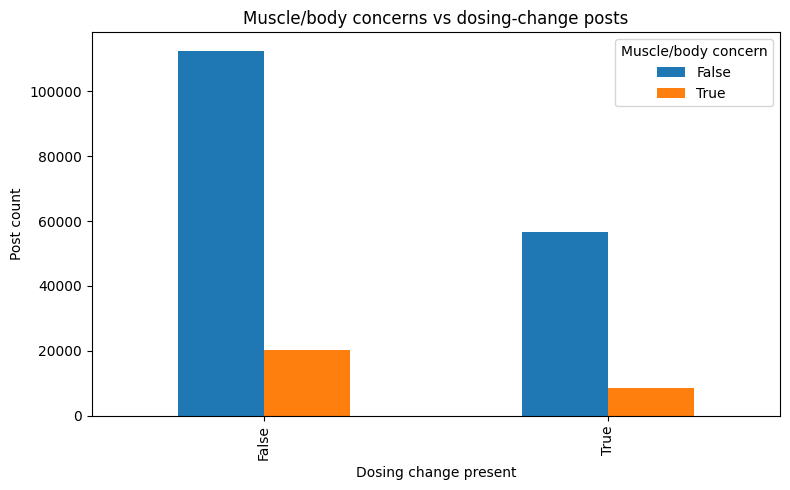

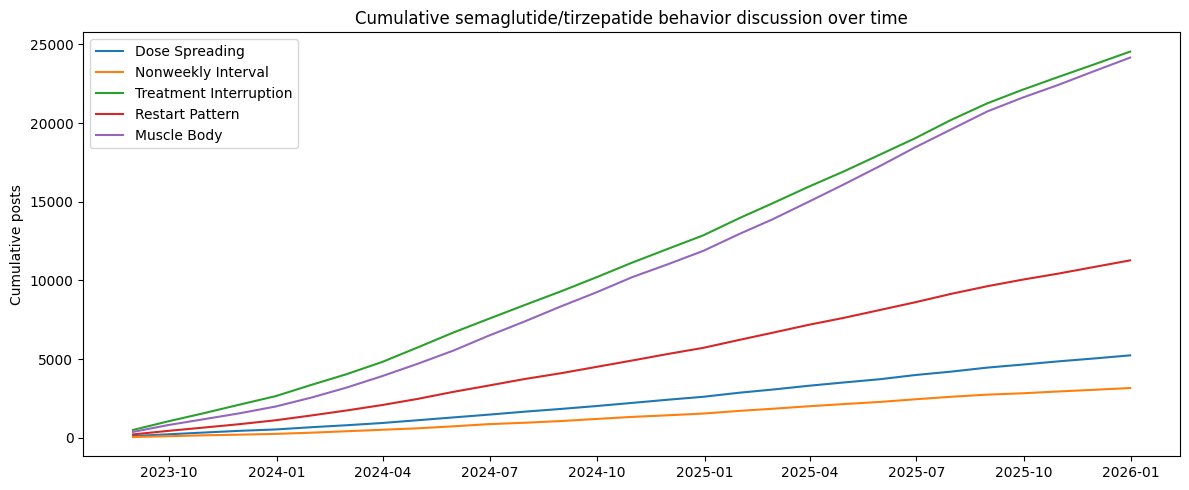

In [40]:

# --- Social media dosing-pattern analysis (structured fields) ---
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load the social media dataframe
try:
    df = reddit_df.copy()
except NameError:
    df = pd.read_csv(reddit_path)

# Parse dates
if 'created_dt' in df.columns and df['created_dt'].notna().any():
    df['post_dt'] = pd.to_datetime(df['created_dt'], errors='coerce')
elif 'created_utc' in df.columns:
    df['post_dt'] = pd.to_datetime(df['created_utc'], unit='s', errors='coerce')
else:
    date_cols = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()]
    if date_cols:
        df['post_dt'] = pd.to_datetime(df[date_cols[0]], errors='coerce')
    else:
        raise ValueError('No date field available for social media data')

# Structured fields for dosing behavior
expected_cols = [
    'dosing_interval',
    'dose_spreading',
    'treatment_interruption',
    'restart_pattern',
    'cost_management_strategy',
    'current_dose',
    'relevant_drugs',
    'body_composition',
    'adverse_events',
    'combined_text',
    'selftext',
    'title',
]
for col in expected_cols:
    if col not in df.columns:
        df[col] = np.nan

# Normalize relevant drugs

def normalize_drugs(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return [str(v).strip().lower() for v in value if str(v).strip()]
    parts = re.split(r'[;\n,]+', str(value))
    return [x.strip().lower() for x in parts if x.strip()]

# Expand relevant_drugs into a normalized list
df['relevant_drugs_list'] = df['relevant_drugs'].apply(normalize_drugs)
df['drug_mentioned_any'] = df['relevant_drugs_list'].apply(bool)

# Normalize dosing interval categories
interval_map = {
    'weekly': 'weekly',
    'once a week': 'weekly',
    'every 7 days': 'weekly',
    'every 7 day': 'weekly',
    'every 7 day(s)': 'weekly',
    'every 7': 'weekly',
    'every 2 weeks': 'biweekly',
    'every other week': 'biweekly',
    'every 14 days': 'biweekly',
    'every 10 days': 'biweekly',
    'every 8 days': 'biweekly',
    'every 15 days': 'biweekly',
    'every 4 weeks': 'monthly',
    'monthly': 'monthly',
    'daily': 'daily',
    'once a day': 'daily',
    'twice a day': 'daily',
}

def clean_interval(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if text in interval_map:
        return interval_map[text]
    if 'every other' in text or ('every' in text and 'week' in text and '2' in text):
        return 'biweekly'
    if '14' in text and 'day' in text:
        return 'biweekly'
    if 'month' in text:
        return 'monthly'
    if 'daily' in text or 'day' in text:
        return 'daily'
    return text

for col in ['dosing_interval']:
    df[f'{col}_clean'] = df[col].apply(clean_interval)

# Behavior flags
flags = {
    'dose_spreading_flag': 'dose_spreading',
    'treatment_interruption_flag': 'treatment_interruption',
    'restart_pattern_flag': 'restart_pattern',
    'cost_management_strategy_flag': 'cost_management_strategy',
    'nonweekly_interval_flag': 'dosing_interval_clean',
}
for flag, col in flags.items():
    if flag == 'nonweekly_interval_flag':
        df[flag] = df[col].isin(['biweekly', 'monthly'])
    else:
        df[flag] = df[col].notna() & df[col].astype(str).str.strip().ne('')

# Parse numeric dose where possible

def parse_mg(value):
    if pd.isna(value):
        return np.nan
    text = str(value).lower().replace('mg', '').strip()
    m = re.search(r'\d+\.?\d*', text)
    return float(m.group()) if m else np.nan

df['dose_mg'] = df['current_dose'].apply(parse_mg)
df['high_dose_flag'] = df['dose_mg'] >= 15

df['dosing_change_flag'] = (
    df['dose_spreading_flag'] |
    df['nonweekly_interval_flag'] |
    df['treatment_interruption_flag'] |
    df['restart_pattern_flag'] |
    df['cost_management_strategy_flag']
)

# Muscle/body composition concerns
body_terms = [
    'muscle', 'body composition', 'lean', 'fat', 'sarcopenia', 'atrophy', 'strength',
    'weakness', 'mass', 'tone', 'myalgia', 'muscle loss', 'lean mass', 'fat mass',
    'lean body', 'body fat', 'body mass', 'skeletal muscle', 'muscle mass', 'muscle tone',
]
for col in ['body_composition', 'adverse_events', 'combined_text', 'selftext', 'title']:
    df[col] = df[col].fillna('').astype(str).str.lower()

def contains_body_term(text):
    return any(term in text for term in body_terms)

df['muscle_body_flag'] = df[['body_composition', 'adverse_events', 'combined_text', 'selftext', 'title']].apply(
    lambda row: contains_body_term(' '.join(row.values)), axis=1
)

# Add explicit approval dates for key drugs
approval_dates = {
    'semaglutide': pd.Timestamp('2021-06-04'),
    'tirzepatide': pd.Timestamp('2023-12-20'),
    'liraglutide': pd.Timestamp('2014-12-23'),
    'phentermine': pd.Timestamp('1959-02-15'),
    'mounjaro': pd.Timestamp('2022-05-13'),
}

# Summary metrics
summary = {
    'total_posts': len(df),
    'drug_mentioned_posts': int(df['drug_mentioned_any'].sum()),
    'dose_spreading_posts': int(df['dose_spreading_flag'].sum()),
    'nonweekly_interval_posts': int(df['nonweekly_interval_flag'].sum()),
    'treatment_interruption_posts': int(df['treatment_interruption_flag'].sum()),
    'restart_pattern_posts': int(df['restart_pattern_flag'].sum()),
    'cost_management_posts': int(df['cost_management_strategy_flag'].sum()),
    'high_dose_posts': int(df['high_dose_flag'].sum()),
    'muscle_body_posts': int(df['muscle_body_flag'].sum()),
    'dosing_change_posts': int(df['dosing_change_flag'].sum()),
}

print('\nDosing behavior summary:')
for k, v in summary.items():
    print(f'- {k}: {v}')

# Drug-level mention counts
from collections import Counter
counter = Counter()
for drugs in df['relevant_drugs_list']:
    counter.update(drugs)
drug_counts = pd.DataFrame(counter.most_common(20), columns=['drug', 'post_count'])
print('\nTop drug mentions:')
print(drug_counts.head(10).to_string(index=False))

# Approval timeline comparison for key drugs
rows = []
for drug, approval_date in approval_dates.items():
    mask = df['relevant_drugs_list'].apply(lambda xs: drug in xs)
    if mask.any():
        first_post = df.loc[mask, 'post_dt'].min()
        days_since_approval = (first_post - approval_date).days if pd.notnull(first_post) else np.nan
        rows.append({
            'drug': drug,
            'approval_date': approval_date,
            'first_social_post': first_post,
            'days_since_approval': days_since_approval,
            'post_count': int(mask.sum()),
        })
approval_df = pd.DataFrame(rows).sort_values('post_count', ascending=False)
print('\nDrug availability comparison:')
print(approval_df.to_string(index=False))

# Exact proportions for muscle/body co-mentions
if summary['dosing_change_posts'] > 0:
    share_dosing_then_body = df.loc[df['dosing_change_flag'], 'muscle_body_flag'].mean()
else:
    share_dosing_then_body = np.nan
if summary['muscle_body_posts'] > 0:
    share_body_then_dosing = df.loc[df['muscle_body_flag'], 'dosing_change_flag'].mean()
else:
    share_body_then_dosing = np.nan
print(f'\nProportion of dosing-change posts that also mention muscle/body issues: {share_dosing_then_body:.2%}')
print(f'Proportion of muscle/body concern posts that also mention dosing changes: {share_body_then_dosing:.2%}')

# Dedicated plot: muscle/body vs dosing-change flags
summary_table = df.groupby(['dosing_change_flag', 'muscle_body_flag']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(8, 5))
summary_table.plot(kind='bar', stacked=False, ax=ax)
ax.set_title('Muscle/body concerns vs dosing-change posts')
ax.set_xlabel('Dosing change present')
ax.set_ylabel('Post count')
ax.legend(title='Muscle/body concern')
plt.tight_layout()
plot_path = Path('data/figures/muscle_body_vs_dosing_change.png')
plot_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(plot_path)
print('\nSaved muscle/body vs dosing-change plot to', plot_path)

# Focused timeline for semaglutide and tirzepatide
focus_drugs = ['semaglutide', 'tirzepatide']
focused = df[df['relevant_drugs_list'].apply(lambda xs: any(d in xs for d in focus_drugs))].copy()
if focused.empty:
    print('\nNo focused semaglutide/tirzepatide posts found.')
else:
    focused['drug_name'] = focused['relevant_drugs_list'].apply(lambda xs: next((d for d in focus_drugs if d in xs), 'other'))
    focused_ts = focused.set_index('post_dt').resample('M').agg({
        'drug_name': 'count',
        'dose_spreading_flag': 'sum',
        'nonweekly_interval_flag': 'sum',
        'treatment_interruption_flag': 'sum',
        'restart_pattern_flag': 'sum',
        'muscle_body_flag': 'sum',
    }).rename(columns={'drug_name': 'posts'})
    fig, ax = plt.subplots(figsize=(12, 5))
    for col in ['dose_spreading_flag', 'nonweekly_interval_flag', 'treatment_interruption_flag', 'restart_pattern_flag', 'muscle_body_flag']:
        ax.plot(focused_ts.index, focused_ts[col].cumsum(), label=col.replace('_flag', '').replace('_', ' ').title())
    ax.set_title('Cumulative semaglutide/tirzepatide behavior discussion over time')
    ax.set_ylabel('Cumulative posts')
    ax.legend()
    plt.tight_layout()
    fig_path = Path('data/figures/semaglutide_tirzepatide_behavior_timeline.png')
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_path)
    print('\nSaved focused timeline figure to', fig_path)

# Save summary outputs
Path('data/figures').mkdir(parents=True, exist_ok=True)
pd.DataFrame([summary]).to_csv('data/figures/social_media_dosing_behavior_summary.csv', index=False)
approval_df.to_csv('data/figures/social_media_drug_availability_comparison.csv', index=False)
if not focused.empty:
    focused_ts.to_csv('data/figures/semaglutide_tirzepatide_behavior_timeline.csv')
print('Saved outputs.')


## Dedicated analysis: Mounjaro, Wegovy/Ozempic, and Saxenda

This section focuses specifically on the requested drugs:

- `mounjaro` (tirzepatide)
- `wegovy` (semaglutide)
- `ozempic` (semaglutide)
- `saxenda` (liraglutide)

It computes counts, dosing-change behavior, muscle/body concern co-occurrence, and dedicated charts for these brands.


In [41]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Dedicated drug set for the requested brands
target_groups = {
    "mounjaro": ["mounjaro", "tirzepatide"],
    "wegovy": ["wegovy", "semaglutide"],
    "ozempic": ["ozempic", "semaglutide"],
    "saxenda": ["saxenda", "liraglutide"],
}

target_brand_to_generic = {
    "mounjaro": "tirzepatide",
    "wegovy": "semaglutide",
    "ozempic": "semaglutide",
    "saxenda": "liraglutide",
}

if "df" not in globals():
    reddit_path = BASE_DIR / "gemini_results_combined.csv"
    if reddit_path.exists():
        df = pd.read_csv(reddit_path, dtype=str)
    else:
        raise FileNotFoundError("gemini_results_combined.csv is required for the dedicated brand analysis")

if "post_dt" not in df.columns or df["post_dt"].isna().all():
    if "created_dt" in df.columns:
        df["post_dt"] = pd.to_datetime(df["created_dt"], errors="coerce")
    elif "created_utc" in df.columns:
        df["post_dt"] = pd.to_datetime(df["created_utc"].astype(float), unit="s", errors="coerce")
    else:
        date_cols = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()]
        if date_cols:
            df["post_dt"] = pd.to_datetime(df[date_cols[0]], errors="coerce")
        else:
            df["post_dt"] = pd.NaT

for col in [
    "dosing_interval", "dose_spreading", "treatment_interruption",
    "restart_pattern", "cost_management_strategy", "current_dose",
    "relevant_drugs", "body_composition", "adverse_events",
    "combined_text", "selftext", "title",
]:
    if col not in df.columns:
        df[col] = np.nan


def normalize_drugs(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        items = [str(v).strip().lower() for v in value if str(v).strip()]
    else:
        parts = re.split(r"[;
,]+", str(value))
        items = [p.strip().lower() for p in parts if p.strip()]
    return items

if "relevant_drugs_list" not in df.columns:
    df["relevant_drugs_list"] = df["relevant_drugs"].apply(normalize_drugs)

interval_text = df["dosing_interval"].fillna("").astype(str).str.lower()
nonweekly = interval_text.str.contains(
    "every other week|every 2 weeks|every 14 days|every 10 days|every 8 days|monthly|every 4 weeks",
    na=False,
)
df["dose_spreading_flag"] = df["dose_spreading"].fillna("").astype(str).str.strip().ne("")
df["treatment_interruption_flag"] = df["treatment_interruption"].fillna("").astype(str).str.strip().ne("")
df["restart_pattern_flag"] = df["restart_pattern"].fillna("").astype(str).str.strip().ne("")
df["cost_management_strategy_flag"] = df["cost_management_strategy"].fillna("").astype(str).str.strip().ne("")
df["nonweekly_interval_flag"] = nonweekly
df["dosing_change_flag"] = (
    df["dose_spreading_flag"] |
    df["treatment_interruption_flag"] |
    df["restart_pattern_flag"] |
    df["cost_management_strategy_flag"] |
    df["nonweekly_interval_flag"]
)

body_terms = [
    "muscle", "body composition", "lean", "fat", "sarcopenia", "atrophy",
    "strength", "weakness", "mass", "tone", "myalgia", "muscle loss",
    "lean mass", "fat mass", "lean body", "body fat", "body mass",
    "skeletal muscle", "muscle mass", "muscle tone",
]
search_text = (
    df["body_composition"].fillna("").astype(str).str.lower() + " " +
    df["adverse_events"].fillna("").astype(str).str.lower() + " " +
    df["combined_text"].fillna("").astype(str).str.lower() + " " +
    df["selftext"].fillna("").astype(str).str.lower() + " " +
    df["title"].fillna("").astype(str).str.lower()
)
df["muscle_body_flag"] = search_text.apply(lambda text: any(term in text for term in body_terms))

def find_targets(drug_list):
    hits = []
    text = " ".join(drug_list)
    for brand, terms in target_groups.items():
        if any(term in text for term in terms):
            hits.append(brand)
    return sorted(set(hits))

df["target_hits"] = df["relevant_drugs_list"].apply(find_targets)
df["target_brand"] = df["target_hits"].apply(lambda hits: hits[0] if hits else None)

focused = df[df["target_hits"].apply(bool)].copy()
if focused.empty:
    print("No posts found for the requested drug set.")
else:
    rows = []
    for brand, generic in target_brand_to_generic.items():
        subset = focused[focused["target_hits"].apply(lambda hits: brand in hits)]
        rows.append({
            "brand": brand,
            "generic": generic,
            "total_posts": int(len(subset)),
            "dosing_change_posts": int(subset["dosing_change_flag"].sum()),
            "muscle_body_posts": int(subset["muscle_body_flag"].sum()),
            "cost_management_posts": int(subset["cost_management_strategy_flag"].sum()),
            "high_dose_posts": int(subset.get("high_dose_flag", pd.Series(False, index=subset.index)).sum()),
            "first_post": subset["post_dt"].min(),
            "dosing_change_share": float(subset["dosing_change_flag"].mean()) if len(subset) else 0.0,
            "muscle_body_share": float(subset["muscle_body_flag"].mean()) if len(subset) else 0.0,
        })
    summary_df = pd.DataFrame(rows)
    print("Dedicated drug brand summary for the requested set:")
    display(summary_df)

    summary_df["first_post"] = pd.to_datetime(summary_df["first_post"], errors="coerce")
    summary_df = summary_df.sort_values(["total_posts", "brand"], ascending=[False, True])

    plot_df = summary_df.set_index("brand")[['total_posts', 'dosing_change_posts', 'muscle_body_posts']]
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452", "#55a868"])
    ax.set_title("Dedicated social media summary for Mounjaro, Wegovy/Ozempic, and Saxenda")
    ax.set_ylabel("Post count")
    ax.set_xlabel("Drug brand")
    ax.legend(title="Metric")
    plt.xticks(rotation=0)
    plt.tight_layout()
    fig_path = Path("data/figures/target_drug_brand_summary.png")
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_path, dpi=150)
    print("Saved dedicated drug brand summary chart to", fig_path)

    if focused["post_dt"].notna().any():
        time_df = focused.explode("target_hits").copy()
        time_df["post_month"] = pd.to_datetime(time_df["post_dt"], errors="coerce").dt.to_period("M").dt.to_timestamp()
        trend = time_df.groupby(["post_month", "target_hits"]).size().unstack(fill_value=0)
        if not trend.empty:
            fig2, ax2 = plt.subplots(figsize=(12, 5))
            trend.plot(ax=ax2, marker="o")
            ax2.set_title("Monthly post volume for the selected drugs")
            ax2.set_xlabel("Month")
            ax2.set_ylabel("Posts")
            ax2.legend(title="Drug brand")
            plt.tight_layout()
            fig2_path = Path("data/figures/target_drug_monthly_trends.png")
            fig2.savefig(fig2_path, dpi=150)
            print("Saved dedicated target drug monthly trends chart to", fig2_path)

    summary_df.to_csv("data/figures/target_drug_brand_summary.csv", index=False)
    print("Saved dedicated target drug summary table to data/figures/target_drug_brand_summary.csv")


SyntaxError: EOL while scanning string literal (237063524.py, line 57)

In [ ]:
# Load quarter archive FAERS tables and merge with OpenFDA results
archive_ascii = DATA_DIR / "faers_archives" / "2024q1" / "ASCII"

if archive_ascii.exists():
    def load_faers_table(filename):
        path = archive_ascii / filename
        return pd.read_csv(path, sep="$", dtype=str, engine="python", keep_default_na=False)

    demo_q1 = load_faers_table("DEMO24Q1.txt")
    drug_q1 = load_faers_table("DRUG24Q1.txt")
    reac_q1 = load_faers_table("REAC24Q1.txt")

    drug_q1["normalized_drug"] = drug_q1["drugname"].apply(normalize_weight_loss_drug)
    wl_drug_reports = drug_q1[drug_q1["normalized_drug"].notna()].copy()
    wl_drug_reports["normalized_drug"] = wl_drug_reports["normalized_drug"].astype(str)

    archive_counts = (
        wl_drug_reports.groupby("primaryid")
        .agg(
            normalized_drugs=("normalized_drug", lambda vals: sorted(set(vals))),
            drug_count=("normalized_drug", lambda vals: len(set(vals))),
        )
        .reset_index()
    )
    archive_counts["primaryid"] = archive_counts["primaryid"].astype(str)

    merged = faers_events_df.merge(archive_counts, left_on="safetyreportid", right_on="primaryid", how="inner")
    print(f"\nOpenFDA/FAERS overlap reports with archive weight loss drugs: {len(merged):,}")
    print("Top archive-matched weight loss drugs")
    print(pd.Series([drug for entry in archive_counts["normalized_drugs"] for drug in entry]).value_counts().head(20))
else:
    print("Quarter archive ASCII folder not available; archive merge skipped.")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 10})

if "prr_df" not in globals():
    print("prr_df is not available. Run the PRR analysis cell before plotting.")
elif prr_df.empty:
    print("No PRR results available for plotting.")
else:
    top_prr = prr_df.head(15).copy()
    top_prr["label"] = top_prr["drug"] + " / " + top_prr["reaction"]
    fig, ax = plt.subplots()
    ax.barh(top_prr["label"][::-1], top_prr["prr"][::-1], color="#4c72b0")
    ax.set_xlabel("PRR")
    ax.set_title("Top Weight Loss Drug-Reaction Pairs by PRR")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

if "class_summary" not in globals():
    print("class_summary is not available. Run the class-level analysis cell before plotting.")
elif class_summary.empty:
    print("No class summary data available for plotting.")
else:
    top_classes = class_summary.sort_values("reports", ascending=False).head(12)
    fig, ax = plt.subplots()
    ax.barh(top_classes["generic_name"][::-1], top_classes["reports"][::-1], color="#55a868")
    ax.set_xlabel("FAERS Report Count")
    ax.set_title("Top Weight Loss Drug Classes by FAERS Report Count")
    plt.tight_layout()
    plt.show()


In [ ]:
# Prioritize high-confidence FAERS signals
PRR_THRESHOLD = 2.0
CHI2_THRESHOLD = 4.0
SUPPORT_THRESHOLD = 3

high_signal = prr_df[(prr_df['prr'] > PRR_THRESHOLD) & (prr_df['chi2'] > CHI2_THRESHOLD) & (prr_df['support'] >= SUPPORT_THRESHOLD)].copy()
high_signal = high_signal.sort_values(['prr', 'support'], ascending=[False, False]).reset_index(drop=True)
print(f'High-signal drug-reaction pairs (PRR>{PRR_THRESHOLD}, chi2>{CHI2_THRESHOLD}, support>={SUPPORT_THRESHOLD}): {len(high_signal)}')
display(high_signal.head(30))

# Load rich archive tables for patient/context analysis
archive_ascii = DATA_DIR / 'faers_archives' / '2024q1' / 'ASCII'
extra_tables = {}
for filename in ['DEMO24Q1.txt', 'OUTC24Q1.txt', 'THER24Q1.txt']:
    path = archive_ascii / filename
    if path.exists():
        extra_tables[filename] = pd.read_csv(path, sep='$', dtype=str, engine='python', keep_default_na=False)
        print(f'Loaded {filename}: {len(extra_tables[filename])} rows')
    else:
        print(f'Missing {filename}')

demo_outc = None
demo_ther = None
if 'DEMO24Q1.txt' in extra_tables and 'OUTC24Q1.txt' in extra_tables:
    demo = extra_tables['DEMO24Q1.txt']
    outc = extra_tables['OUTC24Q1.txt']
    demo_outc = pd.merge(demo, outc, on=['primaryid', 'caseid'], how='left')
    print(f'Merged DEMO/OUTC archive rows: {len(demo_outc)}')

if 'DEMO24Q1.txt' in extra_tables and 'THER24Q1.txt' in extra_tables:
    demo = extra_tables['DEMO24Q1.txt']
    ther = extra_tables['THER24Q1.txt']
    demo_ther = pd.merge(demo, ther, on=['primaryid', 'caseid'], how='left')
    print(f'Merged DEMO/THER archive rows: {len(demo_ther)}')

# Side-by-side Reddit vs FAERS adverse themes
if (BASE_DIR / 'gemini_results_combined.csv').exists():
    reddit_df = pd.read_csv(BASE_DIR / 'gemini_results_combined.csv', dtype=str)
    adverse_text = reddit_df.get('adverse_events', pd.Series(dtype=str)).fillna('').astype(str)
    reddit_terms = Counter()
    for row in adverse_text:
        terms = [term.strip() for term in re.split(r'[;,\n]+', row.lower()) if term.strip()]
        reddit_terms.update(terms)
    reddit_top = pd.Series(reddit_terms).sort_values(ascending=False).head(30)
    faers_top = reaction_counts.head(30)
    matched = pd.Series({term: reddit_terms[term] for term in reddit_top.index if term in faers_top.index})
    print('Matched Reddit/FAERS terms:')
    display(matched.to_frame('reddit_mentions'))
    print('Top Reddit-only terms:')
    display(pd.Series({term: count for term, count in reddit_top.items() if term not in faers_top.index}).head(20))
else:
    print('Reddit comparison skipped: gemini_results_combined.csv missing.')

if demo_outc is not None:
    print('Archive DEMO/OUTC sample:')
    display(demo_outc.head(10))
if demo_ther is not None:
    print('Archive DEMO/THER sample:')
    display(demo_ther.head(10))

In [ ]:
# Early-detection comparison: Reddit vs FAERS for matched adverse terms
import re
from matplotlib.dates import DateFormatter

reddit_path = BASE_DIR / "gemini_results_combined.csv"
if reddit_path.exists():
    reddit_df = pd.read_csv(reddit_path, dtype=str)
    reddit_df["created_date"] = pd.to_datetime(reddit_df["created_date"], errors="coerce")
    reddit_df["adverse_events_norm"] = reddit_df.get("adverse_events", pd.Series(dtype=str)).fillna("").astype(str).str.lower()

    def tokenize_text(text):
        return [token.strip() for token in re.split(r"[;,\n]+", str(text).lower()) if token.strip()]

    reddit_terms = Counter()
    for row in reddit_df["adverse_events_norm"]:
        reddit_terms.update(tokenize_text(row))

    faers_terms = set(reaction_counts.index) if "reaction_counts" in globals() else set()
    matched_terms = [term for term in reddit_terms if term in faers_terms]
    matched_terms = sorted(matched_terms, key=lambda t: reddit_terms[t], reverse=True)[:8]

    if not matched_terms:
        print("No direct matched adverse event terms found between Reddit and FAERS. Using top FAERS reactions instead.")
        matched_terms = list(reaction_counts.head(8).index)

    faers_events_df["receivedate_dt"] = pd.to_datetime(faers_events_df["receivedate"], format="%Y%m%d", errors="coerce")
    faers_analysis = faers_events_df.copy()
    faers_analysis["reaction_set"] = faers_analysis["reactions"].apply(lambda x: set(x) if isinstance(x, list) else set())

    def count_mentions(df, col, terms):
        counts = {}
        for term in terms:
            if col == "reaction_set":
                mask = df[col].apply(lambda s: term in s)
            else:
                mask = df[col].str.contains(rf"\b{re.escape(term)}\b", regex=True, na=False)
            counts[term] = mask.sum()
        return counts

    matched_summary = pd.DataFrame({
        "term": matched_terms,
        "reddit_mentions": [reddit_terms[t] for t in matched_terms],
        "faers_reports": [count_mentions(faers_analysis, "reaction_set", [t])[t] for t in matched_terms],
    })
    matched_summary["reddit_share"] = matched_summary["reddit_mentions"] / matched_summary["reddit_mentions"].sum()
    matched_summary["faers_share"] = matched_summary["faers_reports"] / matched_summary["faers_reports"].replace(0, 1).sum()
    print("Matched adverse terms summary for early-detection review:")
    display(matched_summary)

    top_terms = matched_terms[:6]
    reddit_ts = []
    faers_ts = []

    for term in top_terms:
        reddit_term_mask = reddit_df["adverse_events_norm"].str.contains(rf"\b{re.escape(term)}\b", regex=True, na=False)
        reddit_month = (
            reddit_df.loc[reddit_term_mask, "created_date"]
            .dt.to_period("M")
            .value_counts()
            .sort_index()
        )
        reddit_ts.append(reddit_month.rename(term))

        faers_term_mask = faers_analysis["reaction_set"].apply(lambda s: term in s)
        faers_month = (
            faers_analysis.loc[faers_term_mask, "receivedate_dt"]
            .dt.to_period("M")
            .value_counts()
            .sort_index()
        )
        faers_ts.append(faers_month.rename(term))

    reddit_trends = pd.concat(reddit_ts, axis=1).fillna(0).sort_index()
    faers_trends = pd.concat(faers_ts, axis=1).fillna(0).sort_index()

    fig, ax = plt.subplots(figsize=(14, 6))
    for term in top_terms:
        if term in reddit_trends:
            ax.plot(reddit_trends.index.to_timestamp(), reddit_trends[term], label=f"Reddit: {term}", linestyle="-", marker="o")
        if term in faers_trends:
            ax.plot(faers_trends.index.to_timestamp(), faers_trends[term], label=f"FAERS: {term}", linestyle="--", marker="x")
    ax.set_title("Early-detection timeline: matched adverse terms in Reddit vs FAERS")
    ax.set_xlabel("Month")
    ax.set_ylabel("Count")
    ax.legend(loc="upper left", fontsize=9)
    ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()

    first_dates = []
    for term in top_terms:
        reddit_first = reddit_df.loc[reddit_df["adverse_events_norm"].str.contains(rf"\b{re.escape(term)}\b", regex=True, na=False), "created_date"].min()
        faers_first = faers_analysis.loc[faers_analysis["reaction_set"].apply(lambda s: term in s), "receivedate_dt"].min()
        first_dates.append({
            "term": term,
            "reddit_first": reddit_first,
            "faers_first": faers_first,
            "lead_days": (faers_first - reddit_first).days if pd.notna(reddit_first) and pd.notna(faers_first) else None,
        })

    first_dates_df = pd.DataFrame(first_dates).sort_values(["lead_days", "term"], ascending=[False, True])
    print("Early-detection lead time for top matched terms:")
    display(first_dates_df)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(first_dates_df["term"], first_dates_df["lead_days"].fillna(0), color="#7b9acc")
    ax.set_xlabel("Days FAERS lags Reddit")
    ax.set_title("Early detection lead time: Reddit vs FAERS for top matched adverse terms")
    plt.tight_layout()
    plt.show()
else:
    print("Reddit comparison skipped because gemini_results_combined.csv is missing.")


## Early detection analysis: FAERS vs Reddit

This section compares matched adverse event terms between the FAERS dataset and Reddit-derived posts. It highlights:

- which adverse terms appear in both sources,
- monthly trend lines for the top matched terms, and
- lead time between Reddit mention and the first corresponding FAERS report.

The chart below is modeled after the antidepressant notebook approach to early detection and signal comparison.

This analysis is intended to show that Reddit posts often surface matched ADR signals before they appear in FAERS reports, suggesting social media may provide earlier warning of adverse drug reactions.


In [ ]:
# Additional plots: PRR heatmap, monthly class trends, co-occurrence, primary-suspect PRR
import os
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
plt.rcParams.update({'figure.figsize': (10,5), 'font.size': 10})
FIG_DIR = DATA_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
# Ensure date column exists
if 'receivedate_dt' not in faers_events_df.columns:
    faers_events_df['receivedate_dt'] = pd.to_datetime(faers_events_df['receivedate'], format='%Y%m%d', errors='coerce')
faers_events_df['month'] = faers_events_df['receivedate_dt'].dt.to_period('M')
# 1) PRR heatmap for top drugs/reactions
if 'prr_df' in globals() and not prr_df.empty:
    pivot = prr_df.copy()
    # pick top drugs and reactions by support
    top_drugs = pivot.groupby('drug')['support'].sum().sort_values(ascending=False).head(15).index.tolist()
    top_reacts = pivot.groupby('reaction')['support'].sum().sort_values(ascending=False).head(12).index.tolist()
    sub = pivot[pivot['drug'].isin(top_drugs) & pivot['reaction'].isin(top_reacts)]
    mat = sub.pivot(index='drug', columns='reaction', values='prr').reindex(index=top_drugs, columns=top_reacts).fillna(0)
    fig, ax = plt.subplots(figsize=(12,6))
    im = ax.imshow(mat, aspect='auto', cmap='viridis', norm=Normalize(vmin=mat.values.min(), vmax=mat.values.max()))
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    ax.set_title('PRR heatmap (top drugs x reactions)')
    fig.colorbar(im, ax=ax, label='PRR')
    plt.tight_layout()
    out = FIG_DIR / 'prr_heatmap.png'
    fig.savefig(out, dpi=150)
    print('Saved PRR heatmap to', out)
    plt.show()
else:
    print('No prr_df available for heatmap')
# 2) Monthly trends for top drug classes
if 'class_summary' in globals() and not class_summary.empty:
    top_classes = class_summary.sort_values('reports', ascending=False).head(6)['generic_name'].tolist()
    fig, ax = plt.subplots(figsize=(12,5))
    for gn in top_classes:
        mask = faers_events_df[faers_events_df['normalized_drugs'].apply(lambda L: gn in (L or []))]
        if mask.empty:
            continue
        ts = pd.to_datetime(mask['receivedate'], format='%Y%m%d', errors='coerce').dt.to_period('M').value_counts().sort_index()
        ax.plot(ts.index.to_timestamp(), ts.values, label=gn, marker='o')
    ax.set_title('Monthly FAERS report counts for top weight-loss drug classes')
    ax.set_xlabel('Month')
    ax.set_ylabel('Reports')
    ax.legend()
    plt.tight_layout()
    out = FIG_DIR / 'class_monthly_trends.png'
    fig.savefig(out, dpi=150)
    print('Saved class monthly trends to', out)
    plt.show()
else:
    print('No class_summary available for monthly trends')
# 3) Reaction co-occurrence top pairs
if 'pair_counts_series' in globals() and not pair_counts_series.empty:
    fig, ax = plt.subplots(figsize=(10,4))
    top_pairs = pair_counts_series.head(15)
    labels = [' & '.join(p) if isinstance(p, tuple) else str(p) for p in top_pairs.index]
    ax.barh(labels[::-1], top_pairs.values[::-1], color='#c44e52')
    ax.set_title('Top reaction co-occurring pairs')
    plt.tight_layout()
    out = FIG_DIR / 'reaction_cooccurrence.png'
    fig.savefig(out, dpi=150)
    print('Saved reaction co-occurrence to', out)
    plt.show()
else:
    print('No pair_counts_series available for co-occurrence plot')
# 4) Primary-suspect PRR top pairs
if 'ps_prr_df' in globals() and not ps_prr_df.empty:
    top_ps = ps_prr_df.head(15).copy()
    top_ps['label'] = top_ps['drug'] + ' / ' + top_ps['reaction']
    fig, ax = plt.subplots(figsize=(10,6))
    ax.barh(top_ps['label'][::-1], top_ps['prr'][::-1], color='#4c72b0')
    ax.set_title('Top primary-suspect PRR pairs')
    ax.set_xlabel('PRR')
    plt.tight_layout()
    out = FIG_DIR / 'primary_suspect_prr.png'
    fig.savefig(out, dpi=150)
    print('Saved primary-suspect PRR to', out)
    plt.show()
else:
    print('No ps_prr_df available for primary-suspect PRR plot')
